## EDA for LUNA25 dataset
This notebook aims at exploring the dataset (image and annotations) and create train-test-val splits.

In [2]:
from pathlib import Path
import os
import pandas as pd
from typing import List

base_path = Path("/opt/data/slow/LUNA25")
labels = base_path / "luna25_nodule_blocks" / "image"
metadata = base_path / "luna25_nodule_blocks" / "metadata"
images = base_path / "luna25_images"
annotations = base_path / "annotations.csv"


## Explore annotations and create splits
Section to explore annotation csv and better understand the dataset

In [1]:
import pandas as pd
from pathlib import Path

csv_path = Path("luna25-annotations.csv")
df = pd.read_csv(csv_path)

df

,PatientID,SeriesInstanceUID,StudyDate,CoordX,CoordY,CoordZ,LesionID,AnnotationID,NoduleID,label,Age_at_StudyDate,Gender
0,100570,1.2.840.113654.2.55.32380467633296345717423514...,19990102,61.14,-163.28,-177.75,1,100570_1_19990102,100570_1,1,63,Male
1,106364,1.2.840.113654.2.55.16930993607533226779708566...,19990102,30.64,-95.96,-128.59,1,106364_1_19990102,106364_1,1,67,Female
2,127302,1.2.840.113654.2.55.13728437630416839550344528...,20000102,-82.53,-27.85,-209.46,1,127302_1_20000102,127302_1,1,61,Male
3,128899,1.2.840.113654.2.55.40415300708683206534849072...,20010102,-38.69,-8.78,-39.43,1,128899_1_20010102,128899_1,1,64,Male
4,215816,1.3.6.1.4.1.14519.5.2.1.7009.9004.241362276021...,19990102,32.89,-37.98,-100.04,1,215816_1_19990102,215816_1,1,69,Female
...,...,...,...,...,...,...,...,...,...,...,...,...
6158,123244,1.2.840.113654.2.55.96785330641884045479008848...,20010102,50.88,55.09,1816.38,1,123244_1_20010102,123244_1,0,73,Female
6159,104196,1.2.840.113654.2.55.67476228289351741200494264...,20000102,84.01,-94.42,1106.82,1,104196_1_20000102,104196_1,0,58,Female
6160,104196,1.2.840.113654.2.55.24806580836056963319112187...,20010102,70.29,-85.76,1904.06,1,104196_1_20010102,104196_1,0,59,Female
6161,204005,1.3.6.1.4.1.14519.5.2.1.7009.9004.291214500058...,19990102,128.81,11.64,-256.59,1,204005_1_19990102,204005_1,0,59,Male


In [2]:
grouped = df.groupby('PatientID')
grouped.nunique()

,SeriesInstanceUID,StudyDate,CoordX,CoordY,CoordZ,LesionID,AnnotationID,NoduleID,label,Age_at_StudyDate,Gender
PatientID,,,,,,,,,,,
100012,2,2,2,2,2,1,2,1,1,2,1
100035,3,3,3,3,3,1,3,1,1,3,1
100069,2,2,6,6,6,3,6,3,1,2,1
100095,3,3,12,12,12,4,12,4,1,3,1
100150,2,2,2,2,2,1,2,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...
218781,1,1,1,1,1,1,1,1,1,1,1
218817,1,1,1,1,1,1,1,1,1,1,1
218829,3,3,3,3,3,1,3,1,1,3,1


### Generate train-test split
The following code creates a balanced (i.e. stratified) train-test split in which the class proportion remains unchanged in both splits. The annotations file has one row for each lesion in the dataset: the training sample is intended to be the CT scan and not the lesion, hence the division should be made on scans and not lesions.

In [27]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# Params
csv_path = Path("luna25-annotations.csv")
random_state = 42

# Load the CSV file
df = pd.read_csv(csv_path, skipinitialspace=True)[["SeriesInstanceUID", "label"]]

grouped = df.groupby(by="SeriesInstanceUID")

grouped_df = grouped['label'].max().reset_index()

# Display class distribution
print("Original class distribution:")
print(grouped_df['label'].value_counts())
print(f"\nTotal samples: {len(grouped_df)}")


Original class distribution:
0    3540
1     529
Name: label, dtype: int64

Total samples: 4069


In [28]:
# Create stratified train-test split (80-20 by default)
train_df, test_df = train_test_split(
    grouped_df, 
    test_size=0.2,  # 20% for test, 80% for train
    stratify=grouped_df['label'],  # This ensures balanced class distribution
    random_state= random_state  # For reproducibility
)

# Verify the split
print("\n" + "="*50)
print("TRAIN SET:")
print(f"Total samples: {len(train_df)}")
print(train_df['label'].value_counts())
print(f"Class proportions:\n{train_df['label'].value_counts(normalize=True)}")

print("\n" + "="*50)
print("TEST SET:")
print(f"Total samples: {len(test_df)}")
print(test_df['label'].value_counts())
print(f"Class proportions:\n{test_df['label'].value_counts(normalize=True)}")



TRAIN SET:
Total samples: 3255
0    2832
1     423
Name: label, dtype: int64
Class proportions:
0    0.870046
1    0.129954
Name: label, dtype: float64

TEST SET:
Total samples: 814
0    708
1    106
Name: label, dtype: int64
Class proportions:
0    0.869779
1    0.130221
Name: label, dtype: float64


In [29]:
# Save the splits to separate CSV files
train_df.to_csv('luna25-train.csv', index=False)
test_df.to_csv('luna25-test.csv', index=False)

print("\n" + "="*50)
print("✓ Files saved:")
print("  - luna25-train.csv")
print("  - luna25-test.csv")


✓ Files saved:
  - luna25-train.csv
  - luna25-test.csv


# Explore image data
Section to explore the images of LUNA25 and the provided annotations

In [1]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from pathlib import Path

# Setup paths
base_path = Path("/opt/data/slow/LUNA25")
images_path = base_path / "luna25_images"
nodule_blocks_path = base_path / "luna25_nodule_blocks"
nodule_images_path = nodule_blocks_path / "image"
nodule_metadata_path = nodule_blocks_path / "metadata"

# List available files
print("Sample image files:")
image_files = sorted(list(images_path.glob("*.mha")))[:5]
for f in image_files:
    print(f"  {f.name}")
print(f"\nTotal scans: {len(list(images_path.glob('*.mha')))}")

print("\nSample nodule block files:")
nodule_files = sorted(list(nodule_images_path.glob("*.npy")))[:5]
for f in nodule_files:
    print(f"  {f.name}")
print(f"\nTotal nodule blocks: {len(list(nodule_images_path.glob('*.npy')))}")

print("\nSample metadata files:")
metadata_files = sorted(list(nodule_metadata_path.glob("*.npy")))[:5]
for f in metadata_files:
    print(f"  {f.name}")
print(f"\nTotal metadata files: {len(list(nodule_metadata_path.glob('*.npy')))}")

Sample image files:
  1.2.840.113654.2.55.10001915497607871704679012670488177360.mha
  1.2.840.113654.2.55.100027385603639997812329606977270090953.mha
  1.2.840.113654.2.55.100199553060090932939760477295777719301.mha
  1.2.840.113654.2.55.100267029693057843237393396736558778216.mha
  1.2.840.113654.2.55.10043806773621973157947561820704227942.mha

Total scans: 4069

Sample nodule block files:
  100012_1_19990102.npy
  100012_1_20000102.npy
  100035_1_19990102.npy
  100035_1_20000102.npy
  100035_1_20010102.npy

Total nodule blocks: 6163

Sample metadata files:
  100012_1_19990102.npy
  100012_1_20000102.npy
  100035_1_19990102.npy
  100035_1_20000102.npy
  100035_1_20010102.npy

Total metadata files: 6163


### Inspect a full CT scan (MHA file)

Loading: 1.2.840.113654.2.55.10001915497607871704679012670488177360.mha

Image shape (Z, Y, X): (168, 512, 512)
Spacing: (0.703125, 0.703125, 2.0)
Origin: (-178.39999389648438, -180.0, -345.8900146484375)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
Data type: int16
Value range: [-3024, 1779]


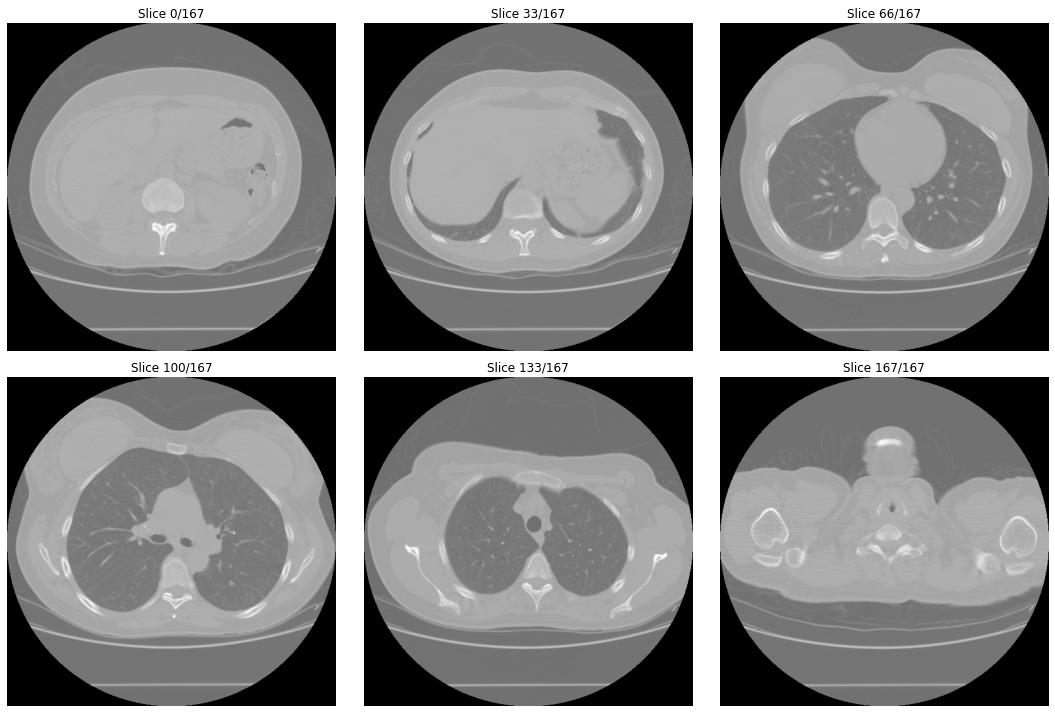


Scan ID: 1.2.840.113654.2.55.10001915497607871704679012670488177360


In [2]:
# Load a sample CT scan
sample_scan_file = list(images_path.glob("*.mha"))[0]
print(f"Loading: {sample_scan_file.name}")

# Read the image using SimpleITK
image = sitk.ReadImage(str(sample_scan_file))
image_array = sitk.GetArrayFromImage(image)

# Get image properties
print(f"\nImage shape (Z, Y, X): {image_array.shape}")
print(f"Spacing: {image.GetSpacing()}")  # (X, Y, Z) spacing in mm
print(f"Origin: {image.GetOrigin()}")
print(f"Direction: {image.GetDirection()}")
print(f"Data type: {image_array.dtype}")
print(f"Value range: [{image_array.min()}, {image_array.max()}]")

# Visualize a few slices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Sample slices at different depths
slice_indices = np.linspace(0, image_array.shape[0] - 1, 6, dtype=int)

for idx, slice_num in enumerate(slice_indices):
    axes[idx].imshow(image_array[slice_num], cmap='gray')
    axes[idx].set_title(f'Slice {slice_num}/{image_array.shape[0]-1}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"\nScan ID: {sample_scan_file.stem}")

### Inspect nodule blocks and metadata

Loading nodule: 100012_1_19990102.npy

Nodule block shape: (64, 128, 128)
Data type: int16
Value range: [-1024.00, 2371.00]

Metadata keys: ['origin', 'spacing', 'transform']

Metadata contents:
  origin: [-154.3999939  -173.80859375  -70.60546875]
  spacing: [2.        0.5859375 0.5859375]
  transform: [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


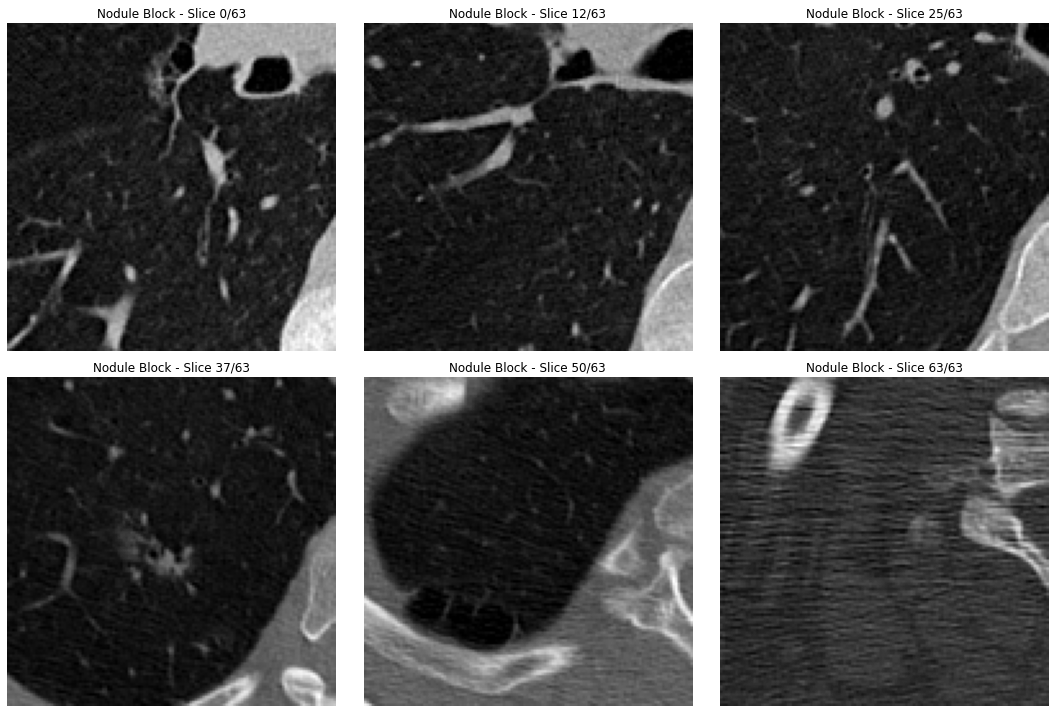

In [32]:
# Load a sample nodule block and its metadata
sample_nodule = list(nodule_images_path.glob("*.npy"))[0]
sample_metadata = nodule_metadata_path / sample_nodule.name

print(f"Loading nodule: {sample_nodule.name}")

# Load nodule block image
nodule_block = np.load(sample_nodule)
print(f"\nNodule block shape: {nodule_block.shape}")
print(f"Data type: {nodule_block.dtype}")
print(f"Value range: [{nodule_block.min():.2f}, {nodule_block.max():.2f}]")

# Load metadata
if sample_metadata.exists():
    metadata = np.load(sample_metadata, allow_pickle=True).item()
    print(f"\nMetadata keys: {list(metadata.keys())}")
    print("\nMetadata contents:")
    for key, value in metadata.items():
        print(f"  {key}: {value}")
else:
    print("\nNo metadata file found!")

# Visualize the nodule block (3D volume)
if len(nodule_block.shape) == 3:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    # Show slices through the center
    slice_indices = np.linspace(0, nodule_block.shape[0] - 1, 6, dtype=int)
    
    for idx, slice_num in enumerate(slice_indices):
        axes[idx].imshow(nodule_block[slice_num], cmap='gray')
        axes[idx].set_title(f'Nodule Block - Slice {slice_num}/{nodule_block.shape[0]-1}')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
elif len(nodule_block.shape) == 4:
    # If it has a channel dimension
    print(f"\nNodule block has 4 dimensions, showing first channel")
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    slice_indices = np.linspace(0, nodule_block.shape[1] - 1, 6, dtype=int)
    
    for idx, slice_num in enumerate(slice_indices):
        axes[idx].imshow(nodule_block[0, slice_num], cmap='gray')
        axes[idx].set_title(f'Nodule Block - Slice {slice_num}/{nodule_block.shape[1]-1}')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Verify MedSamV2 masks
The following code aims at verifying that nodule ids are preserved in MedSamV2 masks

In [1]:
import pandas as pd
from pathlib import Path

csv_path = Path("luna25-annotations.csv")
df = pd.read_csv(csv_path)

In [3]:
masks_path = base_path / "MedSAMv2_masks"

# Get all mask files
all_mask_files = sorted(list(masks_path.glob("*.nii.gz")))

print(f"Total mask files: {len(all_mask_files)}")

Total mask files: 4069


In [ ]:
import SimpleITK as sitk
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm


def verify_mask(mask_file):
    series_uid = mask_file.name.replace(".nii.gz", "")
    try:
        # Load the mask
        mask_img = sitk.ReadImage(str(mask_file))
        mask_arr = sitk.GetArrayFromImage(mask_img)
        
        # Get unique IDs present in the mask
        unique_ids_in_mask = np.unique(mask_arr)
        
        return series_uid, unique_ids_in_mask
        
    except Exception as e:
        print(f"Error processing {mask_file.name}: {e}")
        return 0, []

# Use ThreadPoolExecutor for parallel processing
# Adjust max_workers based on your CPU/IO capabilities (e.g., 4, 8, or None for default)
with ThreadPoolExecutor(max_workers=16) as executor:
    # map returns an iterator, tqdm wraps it for the progress bar
    results = list(tqdm(executor.map(verify_mask, all_mask_files), total=len(all_mask_files)))



In [21]:
df_mask = pd.DataFrame(results, columns=["SeriesInstanceUID", "UniqueValues"])
# Add num_unique column
df_mask["num_lesions"] = df_mask["UniqueValues"].apply(lambda x : len(x)-1)

df_mask.to_csv("masks_unique_values.csv", index=False)

In [ ]:
series_groups = df.groupby(by="SeriesInstanceUID", as_index=False)
df_lesions = series_groups.nunique()[["SeriesInstanceUID","LesionID"]]
df_lesions = df_lesions.rename(columns={"LesionID": "num_lesions"})


Index(['SeriesInstanceUID', 'num_lesions'], dtype='object')

In [46]:
df_lesions_masks = df_lesions.merge(df_mask, on="SeriesInstanceUID", how="left", suffixes=("_gt","_mask"))
df_lesions_masks["count_difference"] = df_lesions_masks["num_lesions_gt"] - df_lesions_masks["num_lesions_mask"]
len(df_lesions_masks.loc[df_lesions_masks["count_difference"] != 0 ])

0

# Inspect analytics from nnDetection preprocessing

In [1]:
import pandas as pd

dataset_properties = pd.read_pickle('properties/dataset_properties.pkl')
intensity_properties = pd.read_pickle('properties/intensity_properties.pkl')
props_per_case = pd.read_pickle('properties/props_per_case.pkl')
plan = pd.read_pickle('properties/D3V001_3d.pkl')




In [18]:
import numpy as np

print("="*60)
print("nnDetection Plan Summary")
print("="*60)

print(f"\nPlan keys: {list(plan.keys())}")
print(f"\nChosen spacing: {plan.get('target_spacing', plan.get('spacing', 'N/A'))}")
print(f"Patch size: {plan.get('patch_size', 'N/A')}")
print(f"Batch size: {plan.get('batch_size', 'N/A')}")
print(f"Architecture: {plan.get('architecture', 'N/A')}")

print("\n" + "="*60)
print("Dataset Properties Summary")
print("="*60)
print(f"\nDataset properties keys: {list(dataset_properties.keys())}")
for k, v in dataset_properties.items():
    if not hasattr(v, '__len__') or isinstance(v, str):
        print(f"  {k}: {v}")
    else:
        print(f"  {k}: (length={len(v)})")

print("\n" + "="*60)
print("Intensity Properties Summary")
print("="*60)
print(f"\nMedian: {intensity_properties.get('median', 'N/A')}")
print(f"Mean:   {intensity_properties.get('mean', 'N/A')}")
print(f"Std:    {intensity_properties.get('std', 'N/A')}")
print(f"Min:    {intensity_properties.get('min', 'N/A')}")
print(f"Max:    {intensity_properties.get('max', 'N/A')}")
print(f"Percentile 00.5: {intensity_properties.get('percentile_00_5', 'N/A')}")
print(f"Percentile 99.5: {intensity_properties.get('percentile_99_5', 'N/A')}")

print("\n" + "="*60)
print("Spacings Summary")
print("="*60)
print(f"\nSpacings shape: {spacings.shape}")
print(f"Median spacing (Z, Y, X): {np.median(spacings, axis=0)}")
print(f"Mean spacing   (Z, Y, X): {np.mean(spacings, axis=0)}")
print(f"Min spacing    (Z, Y, X): {np.min(spacings, axis=0)}")
print(f"Max spacing    (Z, Y, X): {np.max(spacings, axis=0)}")

nnDetection Plan Summary

Plan keys: ['mode', 'target_spacing', 'normalization_schemes', 'use_mask_for_norm', 'anisotropy_threshold', 'resample_anisotropy_threshold', 'target_spacing_percentile', 'dim', 'num_modalities', 'all_classes', 'num_classes', 'transpose_forward', 'transpose_backward', 'dataset_properties', 'planner_id', 'network_dim', 'dataloader_kwargs', 'data_identifier', 'postprocessing', 'patch_size', 'batch_size', 'architecture', 'anchors', 'target_spacing_transposed', 'median_shape_transposed', 'do_dummy_2D_data_aug', 'trigger_lr1']

Chosen spacing: [1.25       0.66406202 0.66406202]
Patch size: [ 96 192 192]
Batch size: 4
Architecture: {'arch_name': 'RetinaUNetV001', 'max_channels': 320, 'start_channels': 32, 'fpn_channels': 128, 'head_channels': 128, 'classifier_classes': 3, 'seg_classes': 3, 'in_channels': 1, 'dim': 3, 'class_weight': [0.25, 0.06863057324840763, 0.6813694267515924, 0.75], 'conv_kernels': [[3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3]

In [5]:
props_per_case['1_2_840_113654_2_55_10001915497607871704679012670488177360']

OrderedDict([('original_size_of_raw_data', array([168, 512, 512])),
             ('original_spacing', array([2.      , 0.703125, 0.703125])),
             ('list_of_data_files',
              [PosixPath('/opt/data/scratch/datasets/nn-datasets/Task023_LUNA25/raw_splitted/imagesTr/1_2_840_113654_2_55_10001915497607871704679012670488177360_0000.nii.gz')]),
             ('seg_file',
              PosixPath('/opt/data/scratch/datasets/nn-datasets/Task023_LUNA25/raw_splitted/labelsTr/1_2_840_113654_2_55_10001915497607871704679012670488177360.nii.gz')),
             ('itk_origin', (-178.39999389648438, -180.0, -345.8900146484375)),
             ('itk_spacing', (0.703125, 0.703125, 2.0)),
             ('itk_direction', (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)),
             ('instances', {'1': 0}),
             ('crop_bbox', [(0, 168), (0, 512), (0, 512)]),
             ('classes', array([-1.,  0.,  1.], dtype=float32)),
             ('size_after_cropping', (168, 512, 512)),
             